<a href="https://colab.research.google.com/github/kushtagra7/hotel_reservation_classification/blob/main/hotel_reservation_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Project Name**    -



##### **Project Type**    - Classification

---

##### **Contribution**    - Individual
##### **Team Member 1 -Kush Tagra**

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [4]:
# Load Dataset
path='/content/drive/MyDrive/Colab Notebooks/Datasets/Hotel Reservations.csv'
df=pd.read_csv(path)
#saving the original dataset
og_df=df.copy()

### Dataset First View

In [5]:
# Dataset First Look
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
df.shape

(36275, 19)

### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


<Axes: >

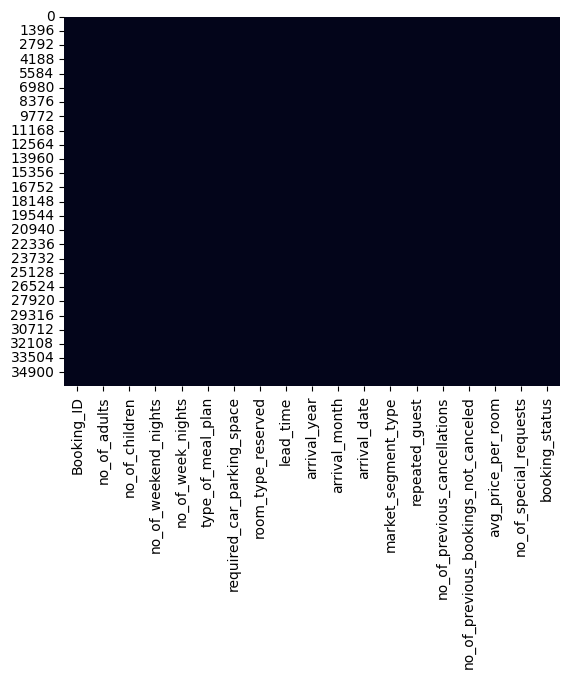

In [10]:
# Visualizing the missing values
sns.heatmap(df.isnull(),cbar=False)

### What did you know about your dataset?

Answer Here

The dataset has no null values, clean values, missing values and hence the dataset is clean.


## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

In [12]:
# Dataset Describe
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


### Variables Description

Answer Here
1. Booking_ID: unique identifier of each booking
2. no_of_adults: Number of adults
3. no_of_children: Number of Children
4. no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
5. no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
6. type_of_meal_plan: Type of meal plan booked by the customer:
7. required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
8. room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
9. lead_time: Number of days between the date of booking and the arrival date
10. arrival_year: Year of arrival date
11. arrival_month: Month of arrival date
12. arrival_date: Date of the month
13. market_segment_type: Market segment designation.
14. repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
15. no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
16. no_of_previous_bookings_not_canceled: Number of previous bookings not
canceled by the customer prior to the current booking
17. avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
18. no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
19. booking_status: Flag indicating if the booking was canceled or not.

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
df.nunique()

,0
Booking_ID,36275
no_of_adults,5
no_of_children,6
no_of_weekend_nights,8
no_of_week_nights,18
type_of_meal_plan,4
required_car_parking_space,2
room_type_reserved,7
lead_time,352
arrival_year,2


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.
# Booking id is a unique identifier
df=df.drop('Booking_ID',axis=1)
df.head()


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


### What all manipulations have you done and insights you found?

Answer Here.

Dropped the column booking id as it is a unique identifier all the reservation made in the hotel and won't contribute to prediction, classification or EDA.

The dataset has no missing values and no null values and hence it is ready for visualisation.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

Text(0.5, 1.0, 'Booking Status')

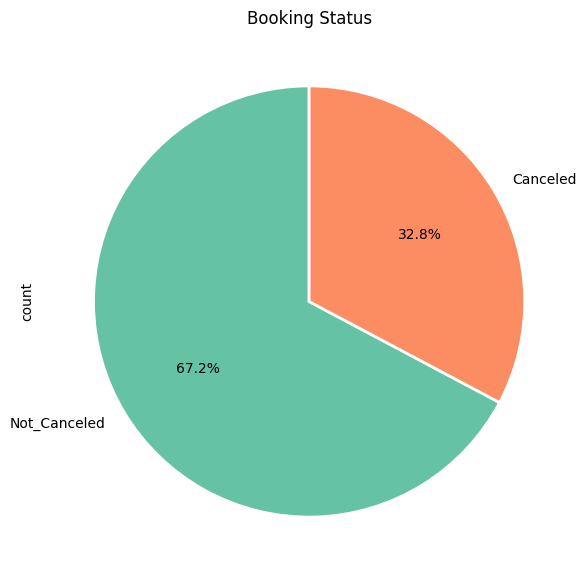

In [15]:
# Chart - 1 visualization code
plt.figure(figsize=(7,7))
booking_status_counts=df['booking_status'].value_counts()
booking_status_counts.plot(kind='pie',colors=sns.color_palette('Set2'),autopct='%1.1f%%',startangle=90,wedgeprops={'edgecolor':'white', 'linewidth':2})
plt.title('Booking Status')


##### 1. Why did you pick the specific chart?

Answer Here.

A pie chart shows the best description of how the reservations are split between not canceled and canceled

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The majority of the reseravtions made are not canceled and actually go through. ALmost one third of the reservations are canceled.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Almost, 1 of every 3 reservations can be canceled.

#### Chart - 2

Text(0, 0.5, 'Average Lead Time')

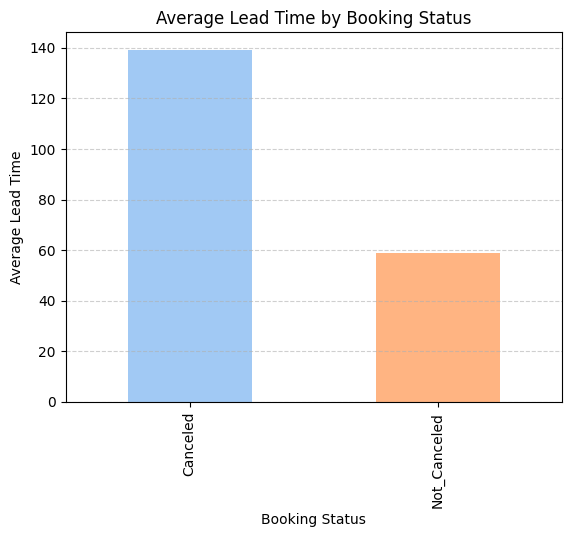

In [16]:
# Chart - 2 visualization code
advance_days=df.groupby('booking_status')['lead_time'].mean()
advance_days.plot(kind='bar',color=sns.color_palette('pastel'))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.title('Average Lead Time by Booking Status')
plt.title('Average Lead Time by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Average Lead Time')

##### 1. Why did you pick the specific chart?

Answer Here.

A bar chart is the best to compare numerical values with categorical values. Here lead days are being compared with whether the booking is canceled or not.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The graph shows that bookings made with more than 60 days in advance have a high chance of cancelation where as bookings made within 60 days of arrival are more likely to go through.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

The graph helps in understanding that booking made in 60+ advance are more likely to get canceled than as compared to the ones made in lesser advance(1-60 days).

The earlier a booking is made, higher the chance is of getting canceled.

#### Chart - 3

/tmp/ipykernel_1080/3692973909.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0, 0.5, 'Average Price per Room')

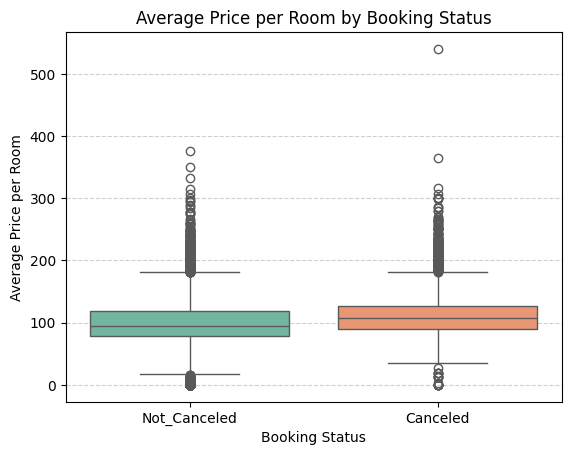

In [17]:
# Chart - 3 visualization code
sns.boxplot(
    data=df,
    x='booking_status',
    y='avg_price_per_room',
    palette='Set2'
)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.title('Average Price per Room by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Average Price per Room')

##### 1. Why did you pick the specific chart?

Answer Here.

A box plot was chosen because it is ideal for comparing the distribution of a numerical variable (avg_price_per_room) across different categories of a categorical variable (booking_status). Unlike a bar chart, it displays the median, interquartile range (IQR), spread of the data, and potential outliers, allowing for a more comprehensive comparison between cancelled and non-cancelled bookings.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The median average room price for cancelled bookings is slightly higher than that of non-cancelled bookings.

The cancelled bookings exhibit a slightly wider spread, indicating greater variability in room prices.

Both booking categories contain numerous high-priced outliers, suggesting that luxury or premium bookings exist regardless of cancellation status.

There is considerable overlap between the two distributions, indicating that room price alone is not sufficient to distinguish cancelled from non-cancelled bookings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

The median average room price for cancelled bookings is slightly higher than that of non-cancelled bookings.
The cancelled bookings exhibit a slightly wider spread, indicating greater variability in room prices.
Both booking categories contain numerous high-priced outliers, suggesting that luxury or premium bookings exist regardless of cancellation status.
There is considerable overlap between the two distributions, indicating that room price alone is not sufficient to distinguish cancelled from non-cancelled bookings.

#### Chart - 4

Text(0, 0.5, 'Cancellation Rate(%)')

<Figure size 1000x1000 with 0 Axes>

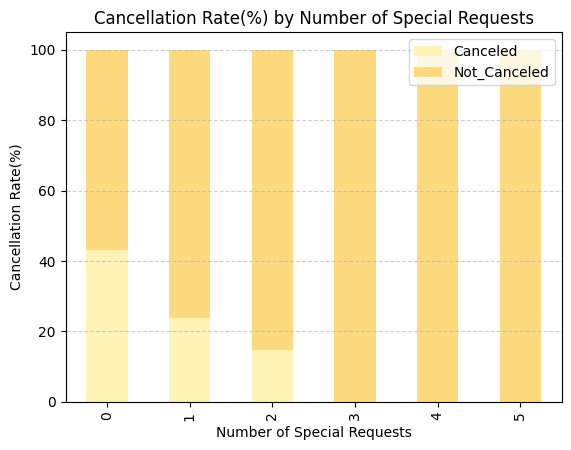

In [18]:
# Chart - 4 visualization code
table=df.groupby('no_of_special_requests')['booking_status'].value_counts().unstack()
cancel_rate=table.div(table.sum(axis=1),axis=0)*100
plt.figure(figsize=(10,10))
cancel_rate.plot(kind='bar',stacked=True,color=sns.color_palette('YlOrBr'))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.title('Cancellation Rate(%) by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate(%)')

##### 1. Why did you pick the specific chart?

Answer Here.

A bar chart was chosen because it is an effective way to compare the cancellation rate across different categories of the number of special requests. It allows for easy comparison of percentages between groups and clearly highlights which categories have higher or lower cancellation rates.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The bar chart indicates that the cancellation rate decreases as the number of special requests increases. Guests who make no or very few special requests have the highest cancellation rates, whereas guests with multiple special requests are less likely to cancel their reservations.

This suggests that customers who make more special requests are generally more engaged with their booking and are therefore more committed to staying at the hotel.

The cancellation rate is 0 when special requests are more than 2.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Send booking reminders or confirmation messages.

Offer incentives to reduce cancellations.

Use no_of_special_requests as an important feature in the machine learning model for predicting booking cancellations.

Improve occupancy planning by identifying high-risk reservations in advance.

#### Chart - 5

Text(0, 0.5, 'Cancellation Rate(%)')

<Figure size 1000x1000 with 0 Axes>

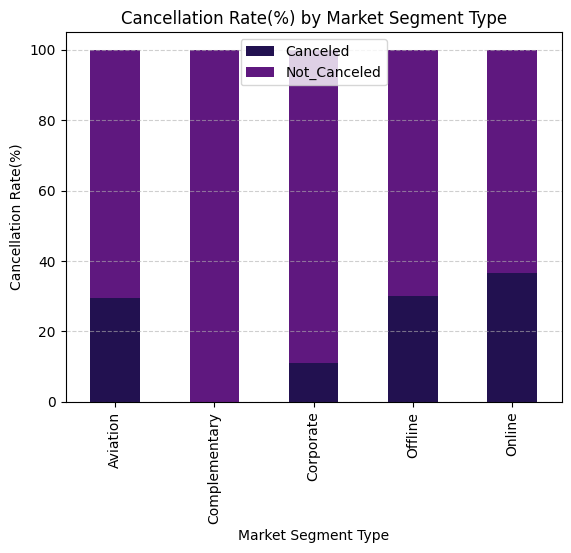

In [19]:
# Chart - 5 visualization code
mkt=df.groupby('market_segment_type')['booking_status'].value_counts().unstack()
mkt_cancel_rate=mkt.div(mkt.sum(axis=1),axis=0)*100
plt.figure(figsize=(10,10))
mkt_cancel_rate.plot(kind='bar',stacked=True,color=sns.color_palette('magma'))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.title('Cancellation Rate(%) by Market Segment Type')
plt.xlabel('Market Segment Type')
plt.ylabel('Cancellation Rate(%)')

##### 1. Why did you pick the specific chart?

Answer Here.

A bar chart was chosen because it is an effective way to compare the cancellation rate across different categories of segments of market. It allows for easy comparison of percentages between groups and clearly highlights which categories have higher or lower cancellation rates.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The complementary reservation have no cancelations. Online reservations have the highest cancelations followed by offline and aviation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Hotels can emphasize on offline booking or keep regulated checks on the line booking while keeping in mind the other factors that can affect the cancelations.

#### Chart - 6

Text(0, 0.5, 'Cancellation Rate(%)')

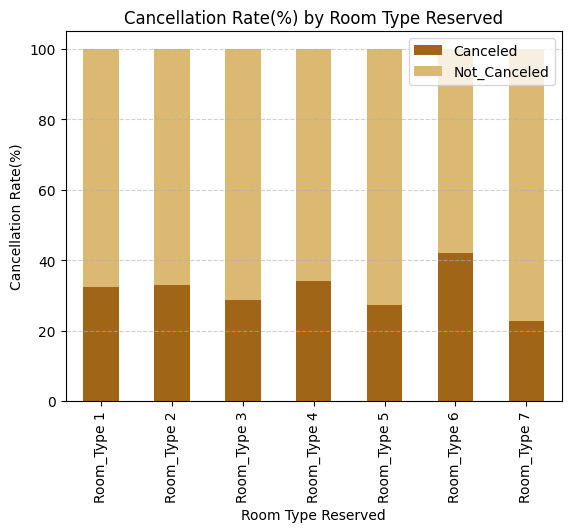

In [20]:
# Chart - 6 visualization code
room=df.groupby('room_type_reserved')['booking_status'].value_counts().unstack()
room_ptage=room.div(room.sum(axis=1),axis=0)*100
room_ptage.plot(kind='bar',stacked=True,color=sns.color_palette('BrBG'))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.title('Cancellation Rate(%) by Room Type Reserved')
plt.xlabel('Room Type Reserved')
plt.ylabel('Cancellation Rate(%)')

##### 1. Why did you pick the specific chart?

Answer Here.

A 100% stacked bar chart was chosen to compare the proportion of cancelled and non-cancelled bookings across different room types. Unlike a simple count plot, this visualization focuses on cancellation rate rather than the number of bookings, making it easier to compare cancellation behavior across room categories regardless of how many bookings each room type received.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

Room_Type 6 has the highest cancellation rate (approximately 42%), indicating that guests reserving this room category are more likely to cancel their bookings.
Room_Type 7 has the lowest cancellation rate (approximately 23%), suggesting that guests booking this room type are more committed to completing their stay.
The remaining room types have cancellation rates ranging between 27% and 34%, indicating moderate differences in customer cancellation behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Identify room categories that are more susceptible to cancellations.

Apply targeted booking policies or promotional offers for high-risk room types.

Improve room inventory management and demand forecasting.

Include room_type_reserved as an important predictive feature in the machine
learning model to improve cancellation prediction accuracy.

In [21]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


#### Chart - 7

Text(0, 0.5, 'Number of Reservations')

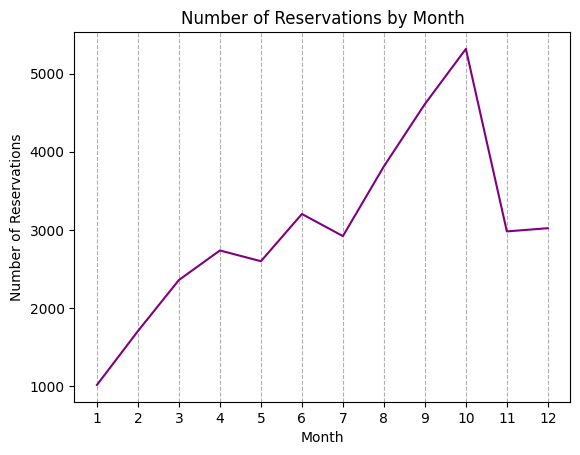

In [22]:
# Chart - 7 visualization code
month_count=df['arrival_month'].value_counts().sort_index()
month_count.plot(kind='line', color='purple')
plt.grid(axis='x', linestyle='--', alpha=1)
plt.xticks(range(1,13))
plt.title('Number of Reservations by Month')
plt.xlabel('Month')
plt.ylabel('Number of Reservations')


##### 1. Why did you pick the specific chart?

Answer Here.

A line chart was chosen because arrival_month represents a chronological sequence. Line charts are ideal for displaying trends over time, making it easy to identify seasonal patterns, peak booking periods, and fluctuations in the number of hotel reservations throughout the year.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that the number of hotel reservations varies considerably across different months, indicating the presence of seasonal booking trends.

Reservations gradually increase from the beginning of the year.
Booking demand reaches its highest point in October (Month 10), making it the busiest month in the dataset.
After October, reservations decline sharply in November and remain relatively stable in December.
The lowest number of reservations occurs in January (Month 1).

These observations suggest that hotel demand is seasonal, with certain months attracting significantly more bookings than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Understanding monthly reservation trends helps hotels make better operational and business decisions. The insights can be used to:
Forecast customer demand more accurately.


Plan staffing and resource allocation during peak and off-peak seasons.

Adjust room pricing based on seasonal demand.

Design promotional campaigns to increase bookings during low-demand months.

#### Chart - 8

Text(0, 0.5, 'Number of Cancelations')

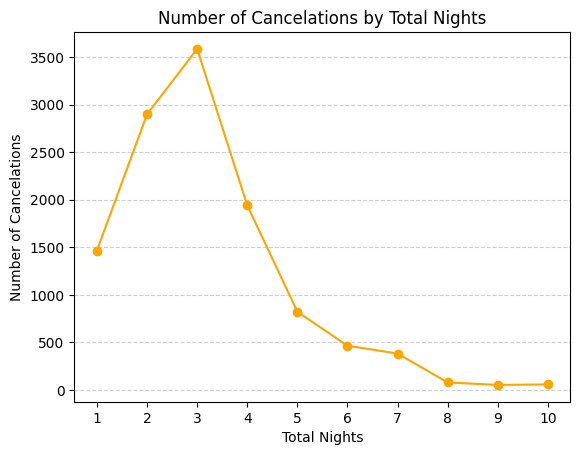

In [91]:
from os import linesep
# Chart - 8 visualization code
df['total_nights']=df['no_of_weekend_nights']+df['no_of_week_nights']
df['total_nights'].value_counts().sort_index()
tot=df.groupby('total_nights')['booking_status'].value_counts().unstack()
tot.loc[1:10, 'Canceled'].plot(kind='line', marker='o',color='orange')
plt.xticks(range(1,11))
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.title('Number of Cancelations by Total Nights')
plt.xlabel('Total Nights')
plt.ylabel('Number of Cancelations')

##### 1. Why did you pick the specific chart?

Answer Here.

Since the Total Nights(x-axis) are in consecutive numbers, a line chart is the most suited to depict the progression of cancelations.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The cancelations peak when the total nights are 3(there is an upward trend). But when the total nights exceed 3, we can see a downward trend in the number of cancelations. Bookings with more than 10 nights have very less values and hence can be neglected.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

The analysis shows that bookings with a stay duration of around 3 nights experience the highest number of cancellations, while cancellations decline for longer stays. Hotels can use this information to identify bookings with higher cancellation risk and implement strategies such as reminder notifications, flexible offers, or confirmation calls for guests planning shorter stays. Additionally, total_nights can serve as a useful feature in the machine learning model for predicting booking cancellations

#### Chart - 9

Text(0, 0.5, 'Cancellation Rate(%)')

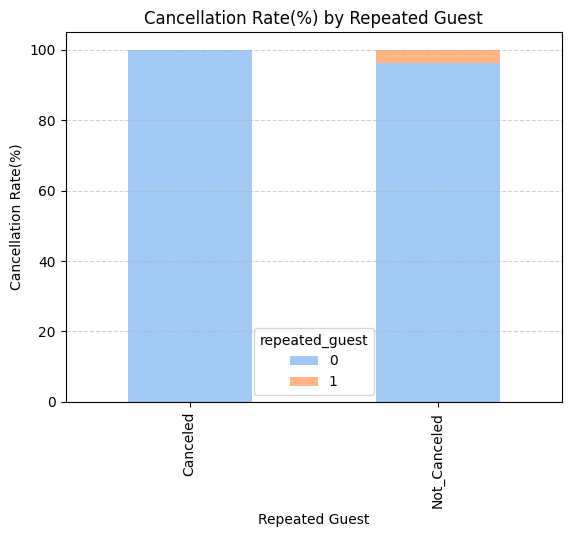

In [105]:
# Chart - 9 visualization code
rep=df.groupby('booking_status')['repeated_guest'].value_counts().unstack()
rep_cancel_rate=rep.div(rep.sum(axis=1),axis=0)*100
rep_cancel_rate.plot(kind='bar',stacked=True,color=sns.color_palette('pastel'))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.title('Cancellation Rate(%) by Repeated Guest')
plt.xlabel('Repeated Guest')
plt.ylabel('Cancellation Rate(%)')


##### 1. Why did you pick the specific chart?

Answer Here.

A 100% stacked bar chart was chosen to compare the distribution of cancelled and non-cancelled bookings between new guests and repeated guests. This visualization makes it easy to compare the relative proportions and understand whether previous hotel experience influences booking cancellation behaviour.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that repeated guests have a much lower proportion of cancelled bookings compared to first-time guests. Most cancellations are associated with new customers, whereas repeated guests are more likely to complete their reservations. This suggests that customer loyalty plays an important role in reducing booking cancellations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

The analysis indicates that repeated guests are more reliable and less likely to cancel their reservations. Hotels can use this insight to:

Strengthen loyalty and membership programs to encourage repeat bookings.


Offer personalized discounts and rewards to returning customers.

Prioritize customer retention strategies, as repeat guests contribute to more
stable occupancy and revenue.


#### Chart - 10

Text(0, 0.5, 'Required Parking(%)')

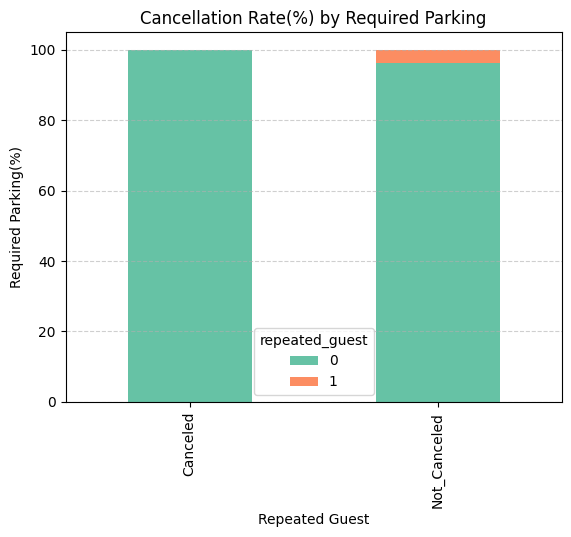

In [110]:
# Chart - 10 visualization code
park=df.groupby('booking_status')['required_car_parking_space'].value_counts().unstack()
park_cancel_rate=rep.div(rep.sum(axis=1),axis=0)*100
park_cancel_rate.plot(kind='bar',stacked=True,color=sns.color_palette('Set2'))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.title('Cancellation Rate(%) by Required Parking')
plt.xlabel('Repeated Guest')
plt.ylabel('Required Parking(%)')

##### 1. Why did you pick the specific chart?

Answer Here.

A 100% stacked bar chart was chosen to compare the distribution of cancelled and non-cancelled bookings between new guests parking spot required or not.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that guests requiring a parking spot have a lower proportion of cancelled bookings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Identify bookings with a parking request as relatively lower-risk reservations.

Offer parking-related packages or bundled services to enhance customer satisfaction and encourage confirmed bookings.

Improve parking space allocation and operational planning based on expected occupancy.

#### Chart - 11

/tmp/ipykernel_1080/3033492799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


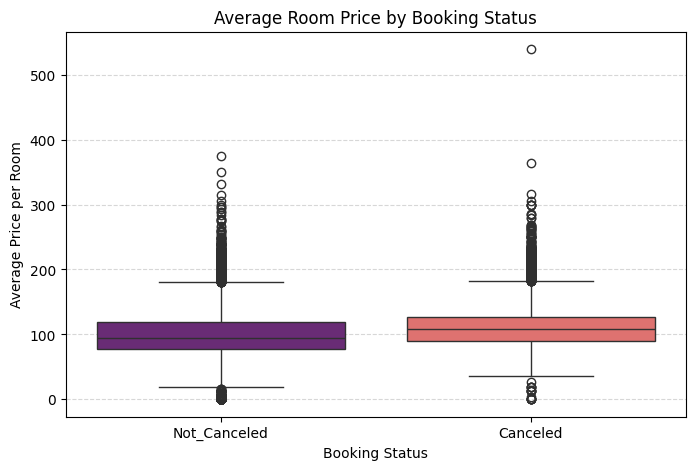

In [115]:
# Chart - 11 visualization code
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='booking_status',
    y='avg_price_per_room',
    palette='magma'
)

plt.title('Average Room Price by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Average Price per Room')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A box plot was chosen because it effectively compares the distribution of average room prices between cancelled and non-cancelled bookings. It displays the median, spread, and outliers, making it easier to identify differences in pricing patterns and detect any unusual booking prices.



##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart indicates that cancelled bookings generally have a higher average room price than non-cancelled bookings, as shown by the higher median and overall distribution. Additionally, both booking categories contain several high-priced outliers, with the cancelled group exhibiting the highest-priced reservations. This suggests that room price is associated with booking cancellation behaviour and may influence a guest's decision to cancel.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

The analysis suggests that higher-priced room bookings are associated with a greater likelihood of cancellation. Hotels can use this insight to:

Monitor premium-priced reservations more closely.
Implement targeted promotions or confirmation reminders for expensive bookings.
Optimize pricing strategies to reduce cancellation risk while maintaining revenue.

#### Chart - 12

Text(0, 0.5, 'Cancellation Rate(%)')

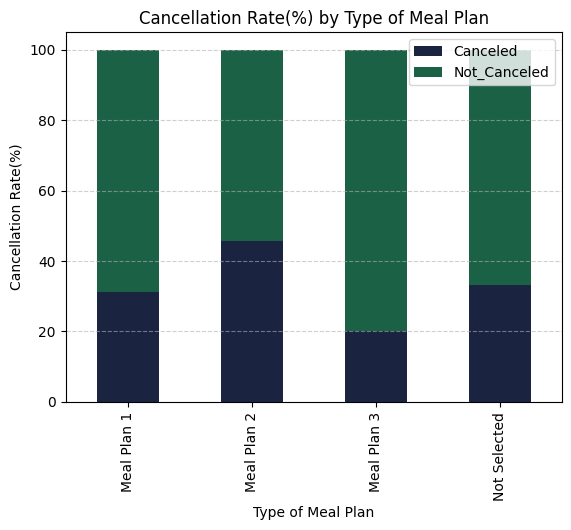

In [124]:
# Chart - 12 visualization code
mp=df.groupby('type_of_meal_plan')['booking_status'].value_counts().unstack()
mp_cancel_rate=mp.div(mp.sum(axis=1),axis=0)*100
mp_cancel_rate.plot(kind='bar',stacked=True,color=sns.color_palette('cubehelix'))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.title('Cancellation Rate(%) by Type of Meal Plan')
plt.xlabel('Type of Meal Plan')
plt.ylabel('Cancellation Rate(%)')

##### 1. Why did you pick the specific chart?

Answer Here.

A stacked bar chart is very helpful to show the disrtibution between cancelations and non-cancelations with respect to the meal plans.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart depcts no certain trend with respect to the type of meal plan. The highest cancelation rate is for meal type 2.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Meal plan is rated to the cancelation of the rooms.

#### Chart - 13

Text(0, 0.5, 'Cancellation Rate(%)')

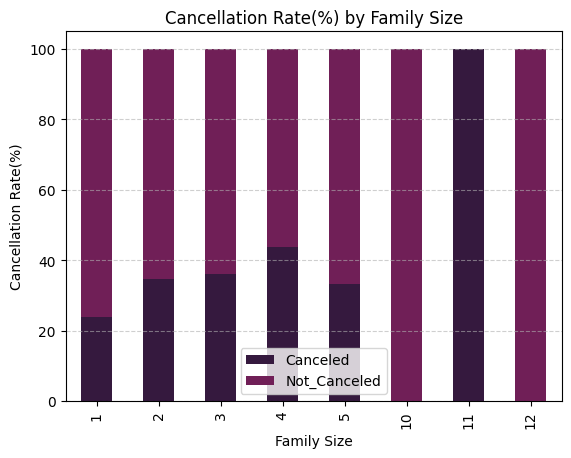

In [126]:
# Chart - 13 visualization code
df['family_size']=df['no_of_adults']+df['no_of_children']
fam=df.groupby('family_size')['booking_status'].value_counts().unstack()
fam_cancel_rate=fam.div(fam.sum(axis=1),axis=0)*100
fam_cancel_rate.plot(kind='bar',stacked=True,color=sns.color_palette('rocket'))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.title('Cancellation Rate(%) by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Cancellation Rate(%)')

##### 1. Why did you pick the specific chart?

Answer Here.

A 100% stacked bar chart was chosen to compare the cancellation rate across different family sizes. This visualization clearly shows the proportion of cancelled and non-cancelled bookings for each family size, helping determine whether the number of guests travelling together is associated with booking cancellation behaviour.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart indicates that family size appears to be associated with booking cancellation behaviour. Among the more common family sizes (1–5), bookings made for 4 guests show the highest proportion of cancellations, while solo travellers (family size 1) have the lowest cancellation proportion. Extremely large family sizes (10–12) have very few observations, so their cancellation percentages should be interpreted with caution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

The analysis suggests that cancellation behaviour differs across family sizes. Hotels can use this insight to:

Design customized offers and booking policies for different group sizes.
Improve room allocation and occupancy planning based on expected guest groups.
Develop family-oriented promotional packages to encourage confirmed bookings.

#### Chart - 14 - Correlation Heatmap

<Axes: >

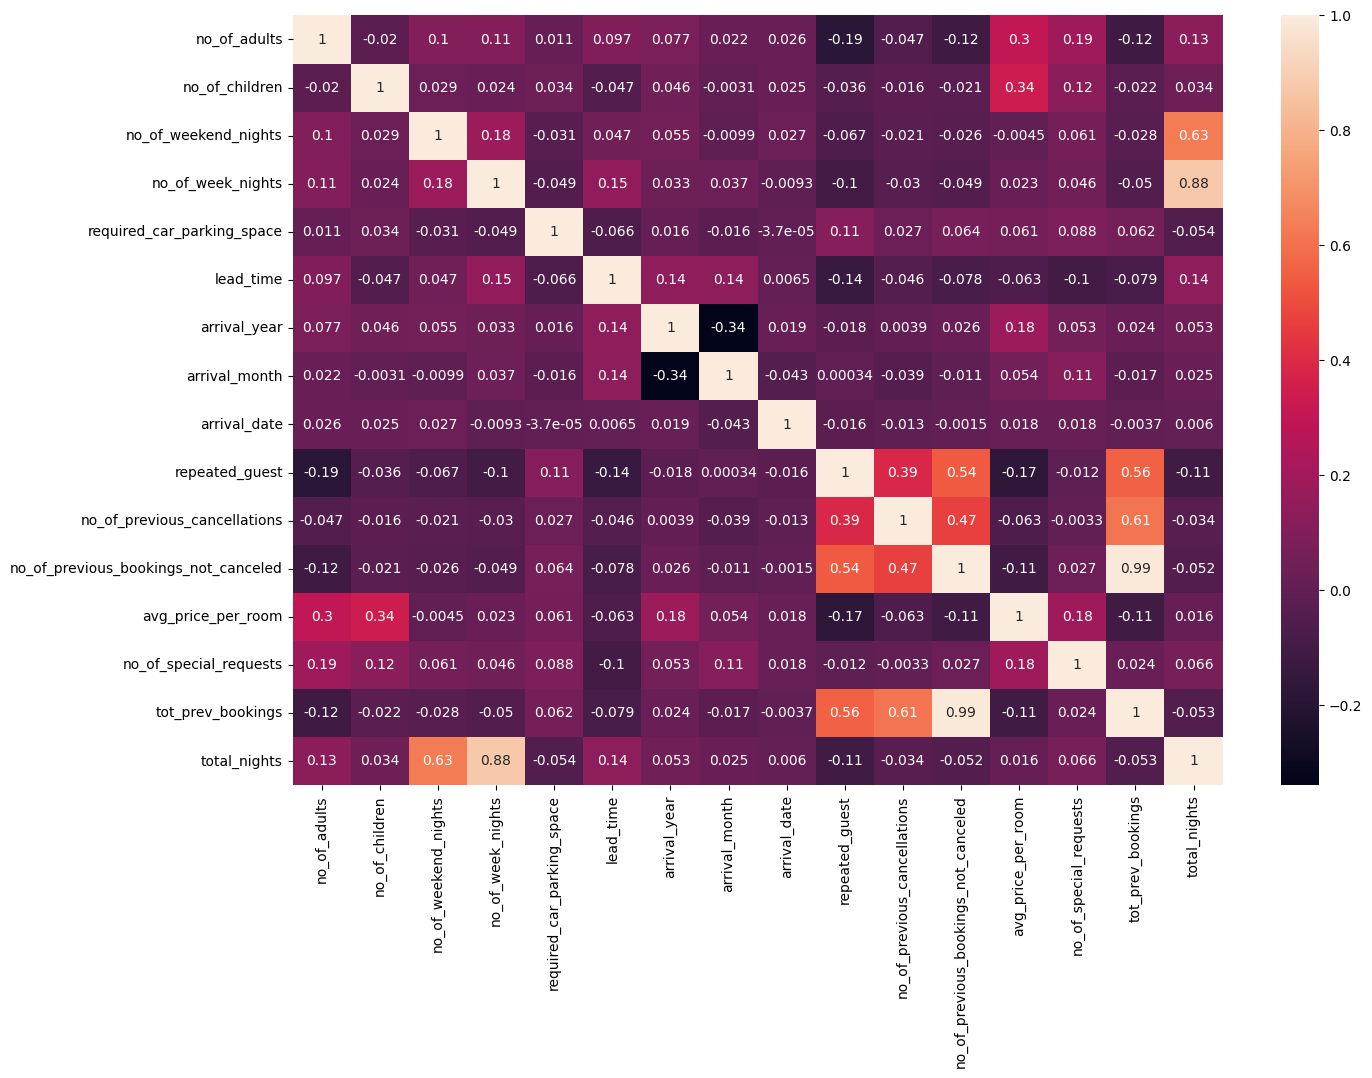

In [107]:
# Correlation Heatmap visualization code
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

##### 1. Why did you pick the specific chart?

Answer Here.

This shows the relation between the numeric features of the datset.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

Shows that the booking status is dependent on previous bookings, cancelations etc.

#### Chart - 15 - Pair Plot

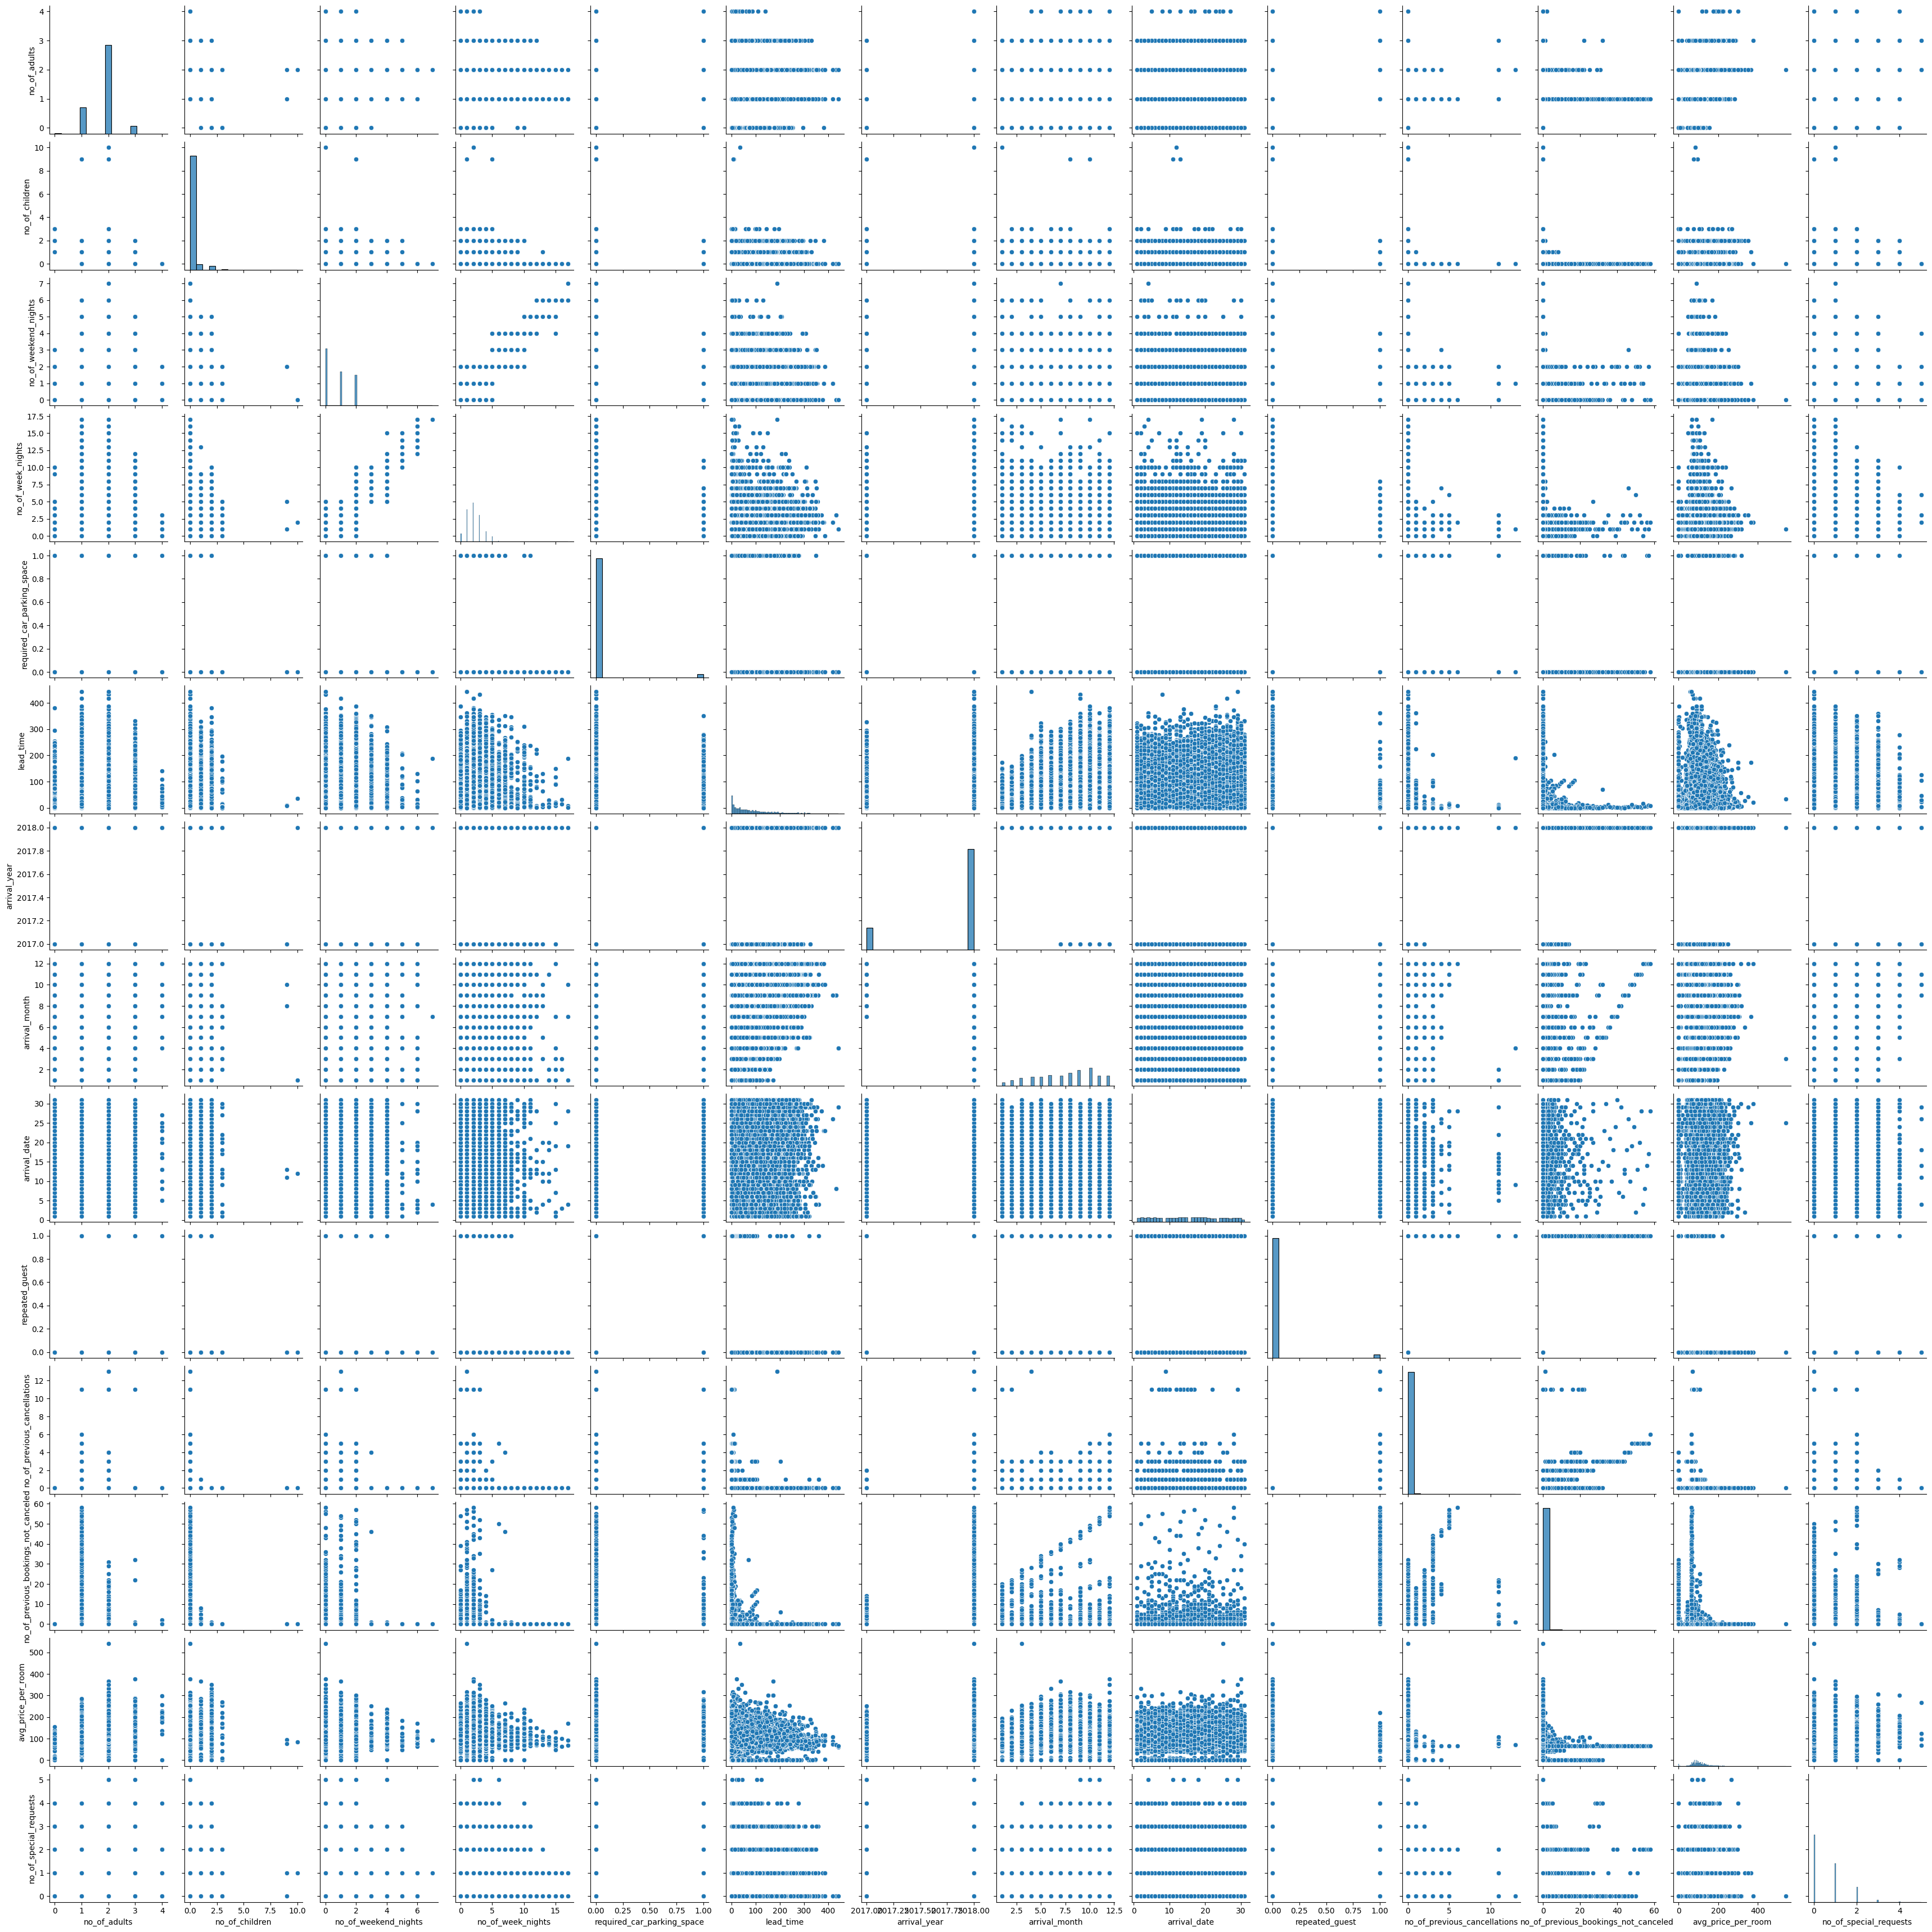

In [30]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

This chart shows the realtion between each pair of features present in the datsaset.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction

#### 2. Lower Casing

In [35]:
# Lower Casing

#### 3. Removing Punctuations

In [36]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords

In [39]:
# Remove White spaces

#### 6. Rephrase Text

In [40]:
# Rephrase Text

#### 7. Tokenization

In [41]:
# Tokenization

#### 8. Text Normalization

In [42]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [43]:
# POS Taging

#### 10. Text Vectorization

In [44]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [46]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [47]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [48]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [49]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [50]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [51]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [52]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [53]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [54]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [55]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***